# Análisis Exploratorio de Fraude en Transacciones con Tarjetas de Crédito

## Grupo 8 - Alabarca Yarlenis, Villarreal Antoine, Otero Felix, Jean

**Dataset a probar:** Credit Card Fraud Detection — Tushar Bhadouria (Kaggle)

## 1. Descargar el dataset

Este dataset contiene más de 20 columnas y la variable objetivo es `is_fraud`:

- `0` = transacción legítima
- `1` = fraude

La descarga se guarda dentro de la carpeta `./data_tushar`.

In [41]:
import kagglehub
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


if not (
    os.path.exists("fraudTrain.csv")
    and os.path.exists("fraudTest.csv")
):
    print("Dataset no encontrado. Descargando desde Kaggle...")

    kagglehub.dataset_download(
        "tusharbhadouria/credit-card-fraud-detection",
        output_dir="."
    )
else:
    print("Dataset ya existe. No es necesario descargarlo.")


Dataset ya existe. No es necesario descargarlo.


## Descripción de las columnas
### Información de la transacción

| Variable | Descripción |
|---|---|
| `trans_date_trans_time` | Fecha y hora en que se realizó la transacción |
| `cc_num` | Número único y anonimizado de la tarjeta de crédito |
| `merchant` | Comercio donde se realizó la transacción |
| `category` | Categoría o tipo de comercio/transacción, por ejemplo: viajes, comida o cuidado personal |
| `amt` | Monto de la transacción |

### Información del titular de la tarjeta
| Variable | Descripción |
|---|---|
| `first`, `last` | Nombre y apellido del titular de la tarjeta |
| `gender` | Género del titular |
| `street`, `city`, `state`, `zip` | Dirección del titular |
| `lat`, `long` | Ubicación geográfica del titular, expresada en latitud y longitud |
| `city_pop` | Población de la ciudad donde reside el titular |
| `job` | Profesión u ocupación del titular |
| `dob` | Fecha de nacimiento del titular |

### Identificadores y tiempo
| Variable | Descripción |
|---|---|
| `trans_num` | Identificador único de la transacción |
| `unix_time` | Fecha y hora de la transacción en formato Unix |

### Información del comercio
| Variable | Descripción |
|---|---|
| `merch_lat`, `merch_long` | Ubicación geográfica del comercio, expresada en latitud y longitud |

### Indicador de fraude
| Variable | Descripción |
|---|---|
| `is_fraud` | Variable objetivo: `1` = fraude, `0` = transacción legítima |

## 2. Cargar los datos

El código identifica automáticamente los CSV que contienen `is_fraud`.


In [7]:
import pandas as pd

df = pd.read_csv("fraudTrain.csv", low_memory=False)

#test = pd.read_csv("fraudTest.csv", low_memory=False)

print("train:", df.shape)


train: (1296675, 23)


In [8]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [9]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='str')

In [10]:
filas, columnas = df.shape
print("Número de filas:", filas)
print("Número de columnas:", columnas)

Número de filas: 1296675
Número de columnas: 23


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

## 3. Calidad de los datos

In [12]:
print("Filas duplicadas:", df.duplicated().sum())

faltantes = pd.DataFrame({
    "Cantidad": df.isnull().sum(),
    "Porcentaje": df.isnull().mean() * 100
})

faltantes.sort_values("Porcentaje", ascending=False)

Filas duplicadas: 0


,Cantidad,Porcentaje
Unnamed: 0,0,0.0
trans_date_trans_time,0,0.0
cc_num,0,0.0
merchant,0,0.0
category,0,0.0
amt,0,0.0
first,0,0.0
last,0,0.0
gender,0,0.0
street,0,0.0


## 4. Variable objetivo

Primero queremos saber qué tan frecuente es el fraude en el dataset.
Como `is_fraud` contiene 0 y 1, su promedio equivale a la proporción de fraudes.

In [13]:
df["is_fraud"].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [14]:
df["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

In [15]:
tasa_base = df["is_fraud"].mean() * 100
print(f"Tasa general de fraude: {tasa_base:.3f}%")

Tasa general de fraude: 0.579%


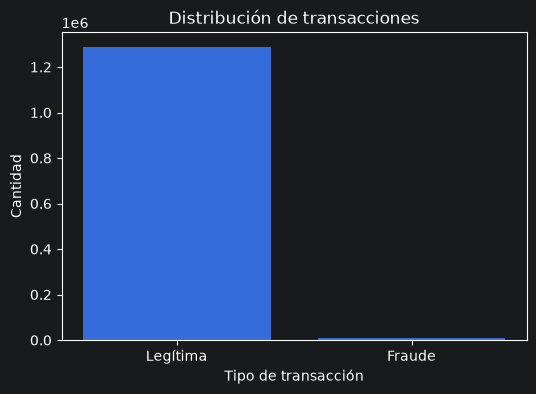

In [16]:
conteos = df["is_fraud"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Legítima", "Fraude"], conteos.values)
plt.title("Distribución de transacciones")
plt.xlabel("Tipo de transacción")
plt.ylabel("Cantidad")
plt.show()

## 5. Crear variables útiles para explorar

El dataset trae fecha/hora, fecha de nacimiento y coordenadas del cliente y del comercio.

A partir de ellas crearemos:

- `transaction_hour`: hora de la transacción.
- `age`: edad aproximada del titular en el momento de la transacción.
- `distance_km`: distancia aproximada entre la ubicación del titular y la del comercio.

Estas variables se derivan de columnas originales; no inventan nuevos registros.

In [17]:
# Fecha y hora
df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"],
    errors="coerce"
)

df["transaction_hour"] = df["trans_date_trans_time"].dt.hour
df["transaction_month"] = df["trans_date_trans_time"].dt.month
df["transaction_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek

df[["trans_date_trans_time", "transaction_hour"]].head()

,trans_date_trans_time,transaction_hour
0,2019-01-01 00:00:18,0
1,2019-01-01 00:00:44,0
2,2019-01-01 00:00:51,0
3,2019-01-01 00:01:16,0
4,2019-01-01 00:03:06,0


In [18]:
# Edad aproximada del titular al momento de la transacción
df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

df["age"] = (
    (df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25
)

df["age"] = df["age"].round(0)

df[["dob", "trans_date_trans_time", "age"]].head()

,dob,trans_date_trans_time,age
0,1988-03-09,2019-01-01 00:00:18,31.0
1,1978-06-21,2019-01-01 00:00:44,41.0
2,1962-01-19,2019-01-01 00:00:51,57.0
3,1967-01-12,2019-01-01 00:01:16,52.0
4,1986-03-28,2019-01-01 00:03:06,33.0


In [19]:
# Distancia aproximada entre el cliente y el comercio usando Haversine
lat1 = np.radians(df["lat"])
lon1 = np.radians(df["long"])
lat2 = np.radians(df["merch_lat"])
lon2 = np.radians(df["merch_long"])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
)

c = 2 * np.arcsin(np.sqrt(a))

df["distance_km"] = 6371 * c

df[["lat", "long", "merch_lat", "merch_long", "distance_km"]].head()

,lat,long,merch_lat,merch_long,distance_km
0,36.0788,-81.1781,36.011293,-82.048315,78.597568
1,48.8878,-118.2105,49.159047,-118.186462,30.212176
2,42.1808,-112.2620,43.150704,-112.154481,108.206083
3,46.2306,-112.1138,47.034331,-112.561071,95.673231
4,38.4207,-79.4629,38.674999,-78.632459,77.556744


# 6. Exploración

### 6.1 Categoría del comercio

In [20]:
fraude_categoria = (
    df.groupby("category")["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_categoria["tasa_fraude_%"] = fraude_categoria["tasa_fraude"] * 100
fraude_categoria["comparacion_tasa_base"] = (
    fraude_categoria["tasa_fraude_%"] / tasa_base
)

fraude_categoria.sort_values("tasa_fraude_%", ascending=False)

,transacciones,fraudes,tasa_fraude,tasa_fraude_%,comparacion_tasa_base
category,,,,,
shopping_net,97543,1713,0.017561,1.756149,3.033778
misc_net,63287,915,0.014458,1.445795,2.497636
grocery_pos,123638,1743,0.014098,1.409761,2.435387
shopping_pos,116672,843,0.007225,0.722538,1.248198
gas_transport,131659,618,0.004694,0.469394,0.810887
misc_pos,79655,250,0.003139,0.313853,0.542188
grocery_net,45452,134,0.002948,0.294817,0.509301
travel,40507,116,0.002864,0.286370,0.494710
entertainment,94014,233,0.002478,0.247835,0.428140


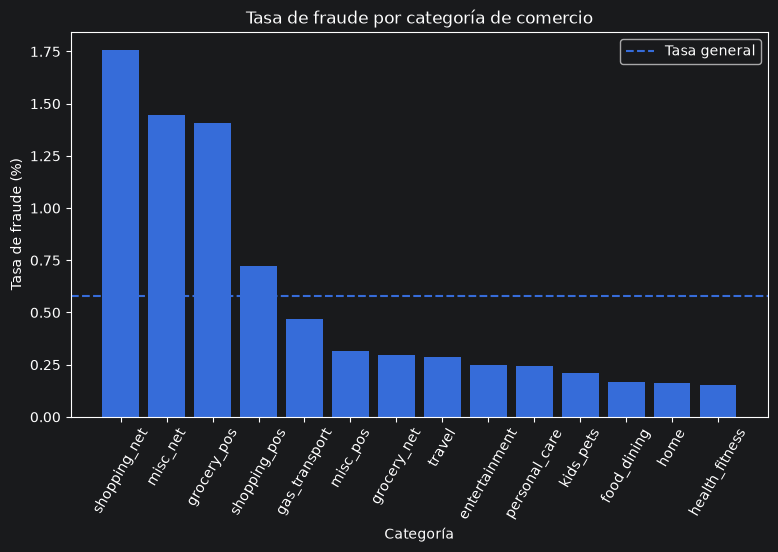

In [21]:
categoria_plot = fraude_categoria.sort_values("tasa_fraude_%", ascending=False)

plt.figure(figsize=(9,5))
plt.bar(categoria_plot.index, categoria_plot["tasa_fraude_%"])
plt.axhline(tasa_base, linestyle="--", label="Tasa general")
plt.title("Tasa de fraude por categoría de comercio")
plt.xlabel("Categoría")
plt.ylabel("Tasa de fraude (%)")
plt.xticks(rotation=60)
plt.legend()
plt.show()

### 6.2 Hora de la transacción

In [22]:
fraude_hora = (
    df.groupby("transaction_hour")["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_hora["tasa_fraude_%"] = fraude_hora["tasa_fraude"] * 100
fraude_hora["comparacion_tasa_base"] = (
    fraude_hora["tasa_fraude_%"] / tasa_base
)

fraude_hora

,transacciones,fraudes,tasa_fraude,tasa_fraude_%,comparacion_tasa_base
transaction_hour,,,,,
0,42502,635,0.014940,1.494047,2.580994
1,42869,658,0.015349,1.534909,2.651582
2,42656,625,0.014652,1.465210,2.531177
3,42769,609,0.014239,1.423929,2.459862
4,41863,46,0.001099,0.109882,0.189824
5,42171,60,0.001423,0.142278,0.245788
6,42300,40,0.000946,0.094563,0.163359
7,42203,56,0.001327,0.132692,0.229228
8,42505,49,0.001153,0.115281,0.199149


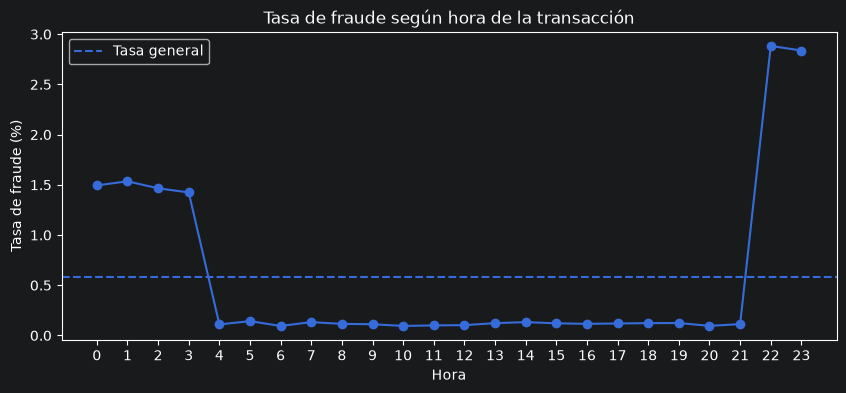

In [23]:
plt.figure(figsize=(10,4))
plt.plot(
    fraude_hora.index,
    fraude_hora["tasa_fraude_%"],
    marker="o"
)
plt.axhline(tasa_base, linestyle="--", label="Tasa general")
plt.title("Tasa de fraude según hora de la transacción")
plt.xlabel("Hora")
plt.ylabel("Tasa de fraude (%)")
plt.xticks(range(24))
plt.legend()
plt.show()

### 6.3 Monto de la transacción

In [24]:
df.groupby("is_fraud")["amt"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
is_fraud,,,,,
0,1289169,67.667110,47.280,1.00,28948.90
1,7506,531.320092,396.505,1.06,1376.04


In [25]:
# Dividir el monto en cuartiles con cantidades similares de observaciones
df["amount_group"] = pd.qcut(
    df["amt"],
    q=4,
    labels=[
        "Monto bajo",
        "Monto medio-bajo",
        "Monto medio-alto",
        "Monto alto"
    ],
    duplicates="drop"
)

fraude_monto = (
    df.groupby("amount_group", observed=False)["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_monto["tasa_fraude_%"] = fraude_monto["tasa_fraude"] * 100
fraude_monto

,transacciones,fraudes,tasa_fraude,tasa_fraude_%
amount_group,,,,
Monto bajo,324325,461,0.001421,0.142141
Monto medio-bajo,324087,1104,0.003406,0.340649
Monto medio-alto,324151,81,0.000250,0.024988
Monto alto,324112,5860,0.018080,1.808017


### 6.4 Edad del titular

In [26]:
df.groupby("is_fraud")["age"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
is_fraud,,,,,
0,1289169,45.981194,44.0,14.0,96.0
1,7506,48.791900,48.0,14.0,94.0


In [27]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 65, 75, 120],
    labels=[
        "Menor de 25",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65-74",
        "75 o más"
    ]
)

fraude_edad = (
    df.groupby("age_group", observed=False)["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_edad["tasa_fraude_%"] = fraude_edad["tasa_fraude"] * 100
fraude_edad

,transacciones,fraudes,tasa_fraude,tasa_fraude_%
age_group,,,,
Menor de 25,131550,838,0.006370,0.637020
25-34,296434,1402,0.004730,0.472955
35-44,269228,1153,0.004283,0.428262
45-54,249305,1436,0.005760,0.576001
55-64,164865,1279,0.007758,0.775786
65-74,94522,556,0.005882,0.588223
75 o más,90771,842,0.009276,0.927609


### 6.5 Distancia entre titular y comercio

In [28]:
df.groupby("is_fraud")["distance_km"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
is_fraud,,,,,
0,1289169,76.113756,78.233012,0.022255,152.117173
1,7506,76.268330,77.931954,0.738769,144.522410


In [29]:
# Crear grupos por cuartiles de distancia
df["distance_group"] = pd.qcut(
    df["distance_km"],
    q=4,
    labels=[
        "Distancia baja",
        "Distancia media-baja",
        "Distancia media-alta",
        "Distancia alta"
    ],
    duplicates="drop"
)

fraude_distancia = (
    df.groupby("distance_group", observed=False)["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_distancia["tasa_fraude_%"] = fraude_distancia["tasa_fraude"] * 100
fraude_distancia

,transacciones,fraudes,tasa_fraude,tasa_fraude_%
distance_group,,,,
Distancia baja,324169,1853,0.005716,0.571615
Distancia media-baja,324169,1921,0.005926,0.592592
Distancia media-alta,324168,1869,0.005766,0.576553
Distancia alta,324169,1863,0.005747,0.574700


### 6.6 Género

In [30]:
fraude_genero = (
    df.groupby("gender")["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_genero["tasa_fraude_%"] = fraude_genero["tasa_fraude"] * 100
fraude_genero

,transacciones,fraudes,tasa_fraude,tasa_fraude_%
gender,,,,
F,709863,3735,0.005262,0.526158
M,586812,3771,0.006426,0.642625


### 6.7 Estado del titular

In [31]:
fraude_estado = (
    df.groupby("state")["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_estado["tasa_fraude_%"] = fraude_estado["tasa_fraude"] * 100

# Evitamos dejarnos engañar por estados con muy pocas observaciones
fraude_estado_filtrado = fraude_estado[
    fraude_estado["transacciones"] >= 500
]

fraude_estado_filtrado.sort_values("tasa_fraude_%", ascending=False).head(15)

,transacciones,fraudes,tasa_fraude,tasa_fraude_%
state,,,,
RI,550,15,0.027273,2.727273
AK,2120,36,0.016981,1.698113
NV,5607,47,0.008382,0.838238
CO,13880,113,0.008141,0.814121
OR,18597,149,0.008012,0.801204
TN,17554,140,0.007975,0.797539
NE,24168,180,0.007448,0.744786
ME,16505,119,0.007210,0.720994
NH,8278,59,0.007127,0.712733


### 6.8 Unicos por variables de ubicacion

In [33]:
variables_ubicacion = [
    "city",
    "state",
    "zip",
    "street",
    "job",
    "merchant"
]

df[variables_ubicacion].nunique()

city        894
state        51
zip         970
street      983
job         494
merchant    693
dtype: int64

### 6.9 Ciudad

In [36]:
fraude_ciudad = (
    df.groupby("city")["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_ciudad["tasa_fraude_%"] = (
    fraude_ciudad["tasa_fraude"] * 100
)

# Solo ciudades con al menos 500 transacciones
fraude_ciudad = fraude_ciudad[
    fraude_ciudad["transacciones"] >= 500
]

fraude_ciudad.sort_values(
    "tasa_fraude_%",
    ascending=False
).head(20)

,transacciones,fraudes,tasa_fraude,tasa_fraude_%
city,,,,
Aurora,512,23,0.044922,4.492188
Clearwater,553,24,0.043400,4.339964
Benton,530,17,0.032075,3.207547
Moscow,516,16,0.031008,3.100775
Howes Cave,504,15,0.029762,2.976190
Riverview,504,15,0.029762,2.976190
Girard,514,15,0.029183,2.918288
Pearlington,529,15,0.028355,2.835539
White Sulphur Springs,529,15,0.028355,2.835539


### 6.91 Codigo postal

In [37]:
fraude_zip = (
    df.groupby("zip")["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_zip["tasa_fraude_%"] = (
    fraude_zip["tasa_fraude"] * 100
)

fraude_zip = fraude_zip[
    fraude_zip["transacciones"] >= 500
]

fraude_zip.sort_values(
    "tasa_fraude_%",
    ascending=False
).head(20)

,transacciones,fraudes,tasa_fraude,tasa_fraude_%
zip,,,,
52760,516,16,0.031008,3.100775
48193,504,15,0.029762,2.976190
12092,504,15,0.029762,2.976190
33760,545,16,0.029358,2.935780
97107,511,15,0.029354,2.935421
30426,514,15,0.029183,2.918288
24986,529,15,0.028355,2.835539
39572,529,15,0.028355,2.835539
11955,502,14,0.027888,2.788845


## State

In [39]:
fraude_estado = (
    df.groupby("state")["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_estado["tasa_fraude_%"] = (
    fraude_estado["tasa_fraude"] * 100
)

fraude_estado = fraude_estado[
    fraude_estado["transacciones"] >= 500
]

fraude_estado.sort_values(
    "tasa_fraude_%",
    ascending=False
).head(20)

,transacciones,fraudes,tasa_fraude,tasa_fraude_%
state,,,,
RI,550,15,0.027273,2.727273
AK,2120,36,0.016981,1.698113
NV,5607,47,0.008382,0.838238
CO,13880,113,0.008141,0.814121
OR,18597,149,0.008012,0.801204
TN,17554,140,0.007975,0.797539
NE,24168,180,0.007448,0.744786
ME,16505,119,0.007210,0.720994
NH,8278,59,0.007127,0.712733


### JOB

In [38]:
fraude_job = (
    df.groupby("job")["is_fraud"]
      .agg(
          transacciones="count",
          fraudes="sum",
          tasa_fraude="mean"
      )
)

fraude_job["tasa_fraude_%"] = (
    fraude_job["tasa_fraude"] * 100
)

fraude_job = fraude_job[
    fraude_job["transacciones"] >= 500
]

fraude_job.sort_values(
    "tasa_fraude_%",
    ascending=False
).head(20)

,transacciones,fraudes,tasa_fraude,tasa_fraude_%
job,,,,
Lawyer,540,28,0.051852,5.185185
TEFL teacher,533,22,0.041276,4.127580
Community development worker,536,22,0.041045,4.104478
Clinical cytogeneticist,508,18,0.035433,3.543307
Writer,504,15,0.029762,2.976190
"Geneticist, molecular",545,16,0.029358,2.935780
"Conservator, museum/gallery",514,15,0.029183,2.918288
Magazine journalist,533,14,0.026266,2.626642
Field trials officer,518,13,0.025097,2.509653


## 7. Comparación rápida para escoger hipótesis

In [32]:
resumen = []

# Categoría con mayor tasa
cat_top = fraude_categoria["tasa_fraude_%"].idxmax()
cat_rate = fraude_categoria.loc[cat_top, "tasa_fraude_%"]
resumen.append([
    "Categoría",
    cat_top,
    cat_rate,
    cat_rate / tasa_base
])

# Hora con mayor tasa
hora_top = fraude_hora["tasa_fraude_%"].idxmax()
hora_rate = fraude_hora.loc[hora_top, "tasa_fraude_%"]
resumen.append([
    "Hora",
    f"{hora_top}:00",
    hora_rate,
    hora_rate / tasa_base
])

# Grupo de edad con mayor tasa
edad_top = fraude_edad["tasa_fraude_%"].idxmax()
edad_rate = fraude_edad.loc[edad_top, "tasa_fraude_%"]
resumen.append([
    "Edad",
    str(edad_top),
    edad_rate,
    edad_rate / tasa_base
])

# Grupo de distancia con mayor tasa
dist_top = fraude_distancia["tasa_fraude_%"].idxmax()
dist_rate = fraude_distancia.loc[dist_top, "tasa_fraude_%"]
resumen.append([
    "Distancia",
    str(dist_top),
    dist_rate,
    dist_rate / tasa_base
])

comparacion = pd.DataFrame(
    resumen,
    columns=[
        "Variable",
        "Grupo con mayor tasa",
        "Tasa de fraude (%)",
        "Veces la tasa general"
    ]
)

comparacion.sort_values("Veces la tasa general", ascending=False)

,Variable,Grupo con mayor tasa,Tasa de fraude (%),Veces la tasa general
1,Hora,22:00,2.882864,4.980200
0,Categoría,shopping_net,1.756149,3.033778
2,Edad,75 o más,0.927609,1.602461
3,Distancia,Distancia media-baja,0.592592,1.023714


## 8. Posibles hipótesis

Después de ejecutar las celdas anteriores, podemos formular candidatos como:

- **Horario:** las transacciones realizadas en determinadas horas presentan una tasa de fraude mayor que el resto.
- **Categoría:** determinadas categorías de comercio presentan una tasa de fraude mayor que otras.
- **Monto:** las transacciones fraudulentas presentan montos diferentes a las legítimas.
- **Distancia:** las transacciones realizadas a mayor distancia de la ubicación del titular presentan una mayor tasa de fraude.
- **Edad:** determinados grupos de edad presentan una tasa de fraude mayor.
